# **Exploratory Data Analysis (EDA)**

The processed LinkedIn job postings data, which was initially stored and analyzed using Hadoop HDFS and Apache Spark, was further explored through Exploratory Data Analysis (EDA). After preprocessing, feature engineering, aggregation, and clustering, the generated results were exported as CSV files and imported into Python for visualization and analysis. The EDA was conducted to gain insights into labor market trends by examining job cluster distributions, salary patterns, experience-level requirements, geographic demand, remote work adoption, sector-wise hiring trends, and skill demand.


# **Import Required Libraries**

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

# **Upload Dataset Files**

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving geo_heatmap.csv to geo_heatmap.csv
Saving sector_demand_geo.csv to sector_demand_geo.csv
Saving sector_monthly_trend.csv to sector_monthly_trend.csv
Saving skill_trend_yoy.csv to skill_trend_yoy.csv
Saving cluster_assignments.csv to cluster_assignments.csv
Saving cluster_profiles.csv to cluster_profiles.csv
Saving kmeans_k_selection.csv to kmeans_k_selection.csv
Saving remote_trend.csv to remote_trend.csv
Saving salary_distribution.csv to salary_distribution.csv
Saving skill_freq_overall.csv to skill_freq_overall.csv


# **Loading the Result Datasets**

In [ ]:
cluster_assignments = pd.read_csv("cluster_assignments.csv")
cluster_profiles = pd.read_csv("cluster_profiles.csv")
geo_heatmap = pd.read_csv("geo_heatmap.csv")
remote_trend = pd.read_csv("remote_trend.csv")
salary_distribution = pd.read_csv("salary_distribution.csv")
sector_demand_geo = pd.read_csv("sector_demand_geo.csv")
sector_monthly_trend = pd.read_csv("sector_monthly_trend.csv")
skill_freq = pd.read_csv("skill_freq_overall.csv")

In [ ]:
for name, df in {
    "Cluster Assignments": cluster_assignments,
    "Cluster Profiles": cluster_profiles,
    "Geo Heatmap": geo_heatmap,
    "Remote Trend": remote_trend,
    "Salary Distribution": salary_distribution,
    "Sector Demand Geo": sector_demand_geo,
    "Sector Monthly Trend": sector_monthly_trend,
    "Skill Frequency": skill_freq
}.items():
    print("\n", "="*50)
    print(name)
    print(df.head())


Cluster Assignments
          job_id      sector          city post_year salary_mid  \
0  JOB3700000001  technology        Dallas       NaN     164500   
1  JOB3700000003  technology       Phoenix       NaN     124500   
2  JOB3700000006  technology        Boston       NaN     235000   
3  JOB3700000015  technology       Phoenix       NaN     265500   
4  JOB3700000020  technology  Philadelphia       NaN     257000   

   experience_level cluster_id  
0         Associate          1  
1       Entry level          0  
2  Mid-Senior level          1  
3  Mid-Senior level          0  
4          Director          1  

Cluster Profiles
   cluster_id  job_count  avg_salary  sector_count  company_count  \
0           0       5540    107903.0            12            124   
1           1        392    166592.0             1             15   
2           2        346    102335.0             1             10   
3           3        550    131101.0             1             10   
4           4  

# **Cluster Size Distribution Analysis**

This visualization shows the number of job postings assigned to each cluster. It helps evaluate how jobs are distributed among the generated clusters and whether any cluster dominates the dataset.

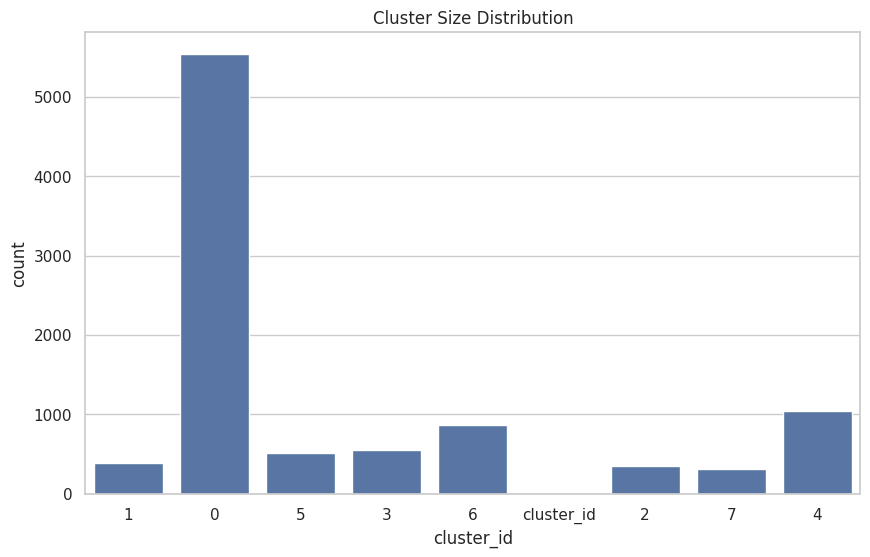

In [ ]:
plt.figure()
sns.countplot(data=cluster_assignments, x="cluster_id")
plt.title("Cluster Size Distribution")
plt.show()

# **Salary Distribution Across Clusters**

A boxplot is used to compare salary distributions among clusters. The graph highlights salary ranges, median salaries, variability, and outliers, enabling comparison of compensation patterns across different job groups.

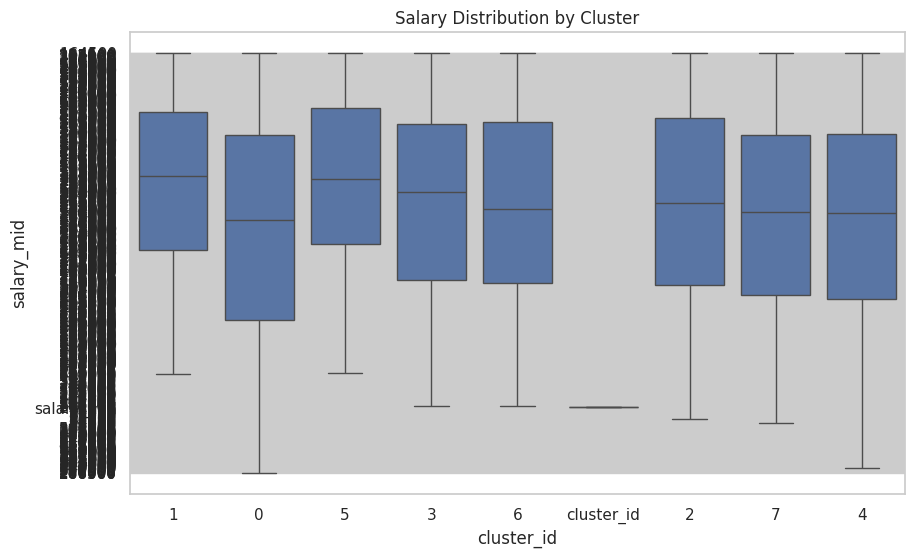

In [ ]:
plt.figure()
sns.boxplot(data=cluster_assignments, x="cluster_id", y="salary_mid")
plt.title("Salary Distribution by Cluster")
plt.show()

# **Experience Level Distribution Across Clusters**

This chart illustrates how different experience levels are distributed within each cluster. It helps identify whether a cluster primarily contains entry-level, mid-level, or senior-level positions.

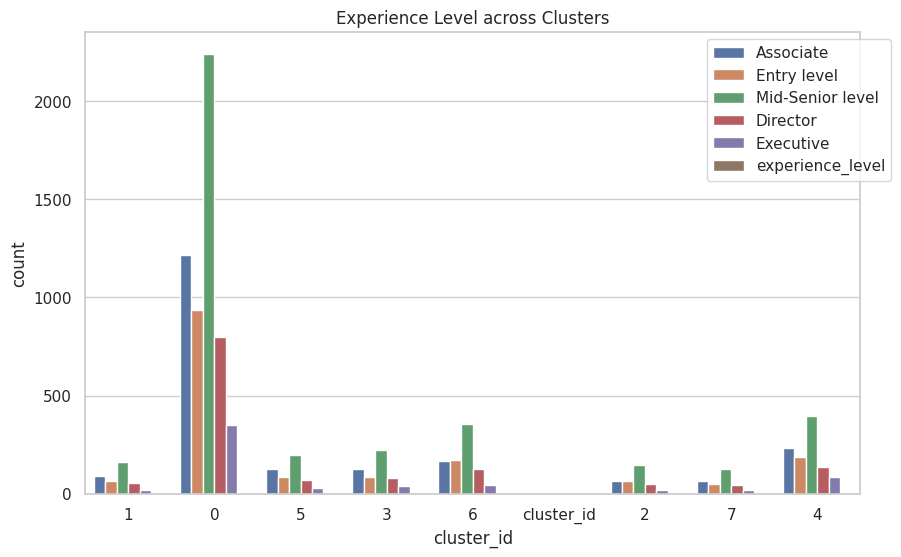

In [ ]:
plt.figure()
sns.countplot(data=cluster_assignments, x="cluster_id", hue="experience_level")
plt.title("Experience Level across Clusters")
plt.legend(bbox_to_anchor=(1.05,1))
plt.show()

# **Average Salary per Cluster**

This visualization compares the average salary of each cluster and helps identify high-paying and low-paying job groups.

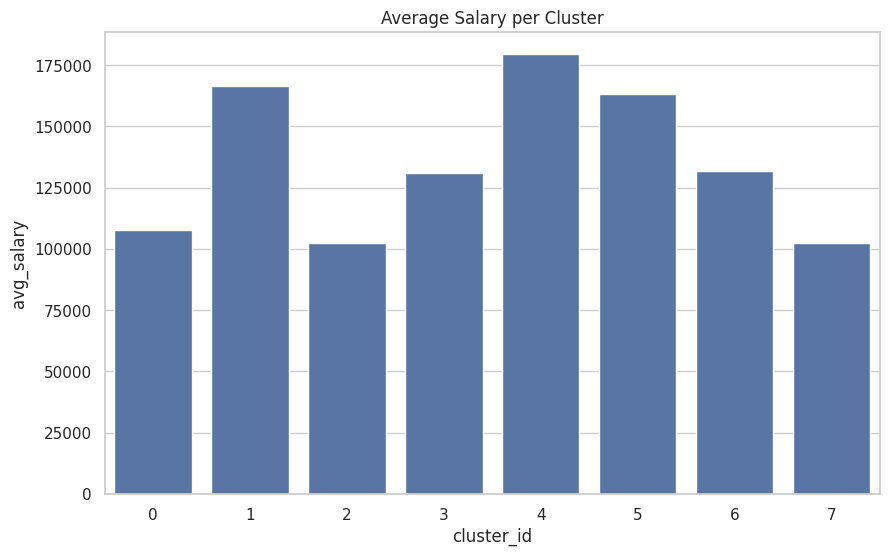

In [ ]:
plt.figure()
sns.barplot(data=cluster_profiles, x="cluster_id", y="avg_salary")
plt.title("Average Salary per Cluster")
plt.show()

# **Job Count per Cluster**

This chart displays the number of jobs within each cluster and provides insight into the relative demand represented by each cluster.

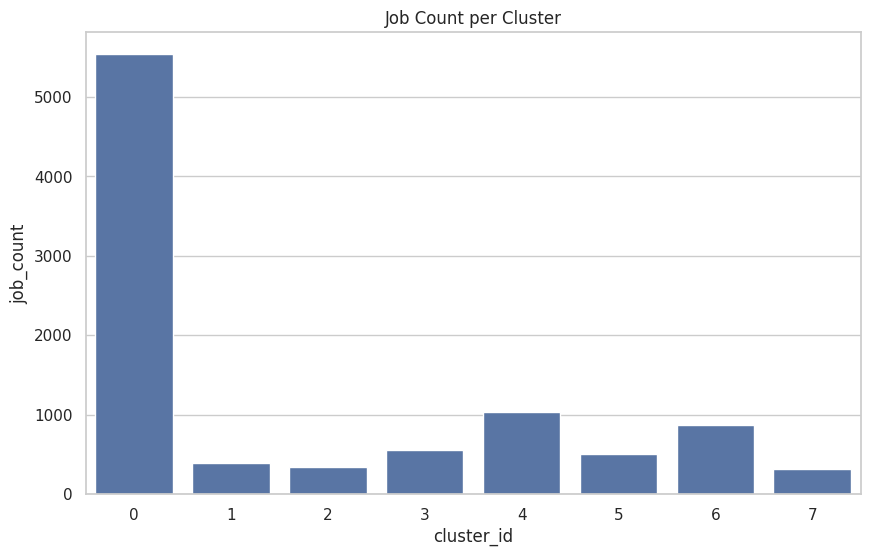

In [ ]:
plt.figure()
sns.barplot(data=cluster_profiles, x="cluster_id", y="job_count")
plt.title("Job Count per Cluster")
plt.show()

# **Geographic Job Density and Salary Heatmap**

This interactive map visualizes geographic job demand and salary levels. Marker size represents job volume, while marker color represents average salary, allowing identification of important labor market regions.

In [ ]:
fig = px.scatter_geo(
    geo_heatmap,
    lat="latitude",
    lon="longitude",
    size="total_jobs",
    color="avg_salary",
    hover_name="city",
    projection="natural earth",
    title="Job Density & Salary Heatmap"
)
fig.show()

# **Total Jobs by City**

This bar chart ranks cities according to the number of job postings and highlights regions with the highest hiring activity.

In [ ]:
fig = px.bar(
    geo_heatmap.sort_values("total_jobs", ascending=False),
    x="city",
    y="total_jobs",
    title="Total Jobs by City"
)
fig.show()

# **Remote Work Trends by Sector**

This analysis compares remote and non-remote job opportunities across industries, helping identify sectors that are more supportive of remote work arrangements.

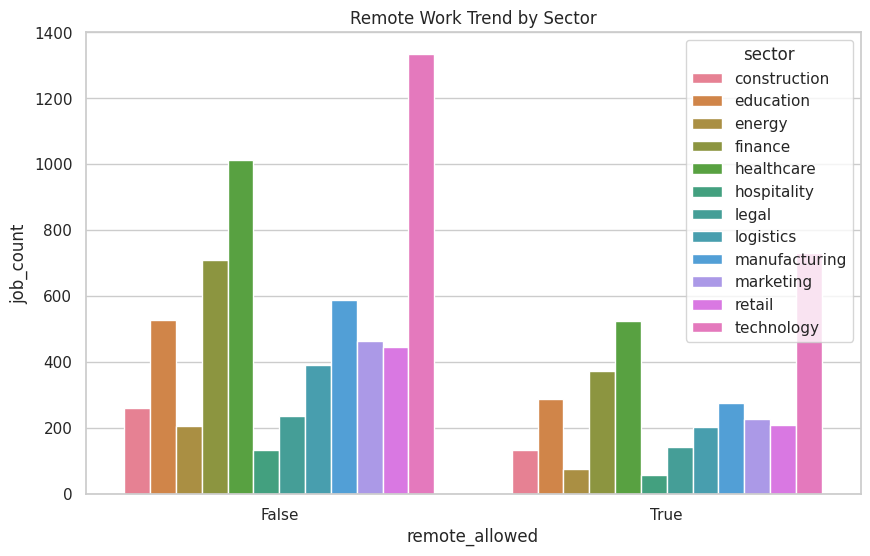

In [ ]:
sns.barplot(data=remote_trend, x="remote_allowed", y="job_count", hue="sector")
plt.title("Remote Work Trend by Sector")
plt.show()

# **Average Salary by Experience Level**

This chart evaluates how salary changes across experience levels and demonstrates the relationship between professional growth and compensation.

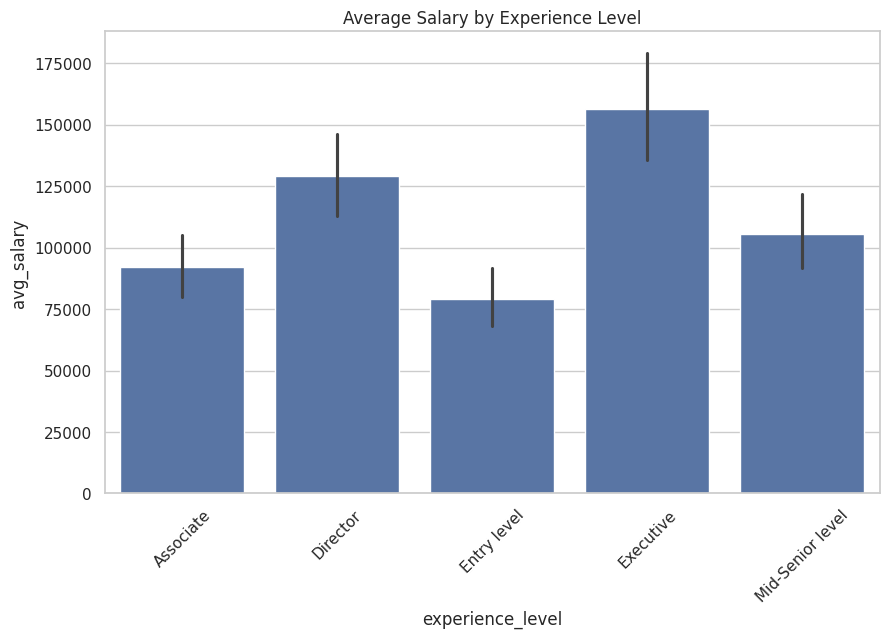

In [ ]:
sns.barplot(data=salary_distribution, x="experience_level", y="avg_salary")
plt.title("Average Salary by Experience Level")
plt.xticks(rotation=45)
plt.show()

# **Salary Band Distribution**

This visualization shows the distribution of jobs across salary bands and identifies the most common salary ranges within the dataset.

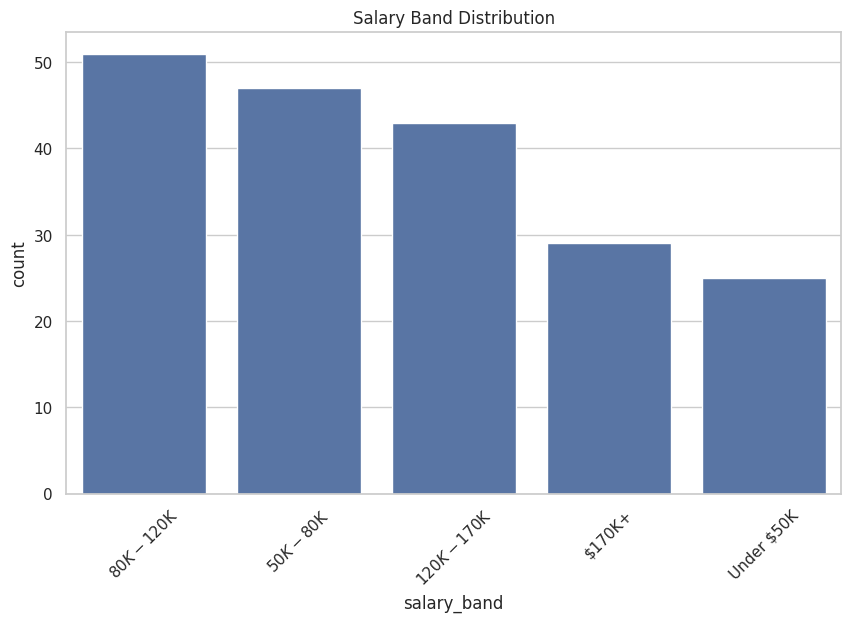

In [ ]:
sns.countplot(data=salary_distribution, x="salary_band", order=salary_distribution["salary_band"].value_counts().index)
plt.title("Salary Band Distribution")
plt.xticks(rotation=45)
plt.show()

# **Sector Demand by City**

This chart compares industry demand across cities and highlights geographical specialization of different sectors.

In [ ]:
fig = px.bar(
    sector_demand_geo,
    x="sector",
    y="job_count",
    color="city",
    title="Sector Demand by City"
)
fig.show()

# **Salary vs Application Rate Analysis**

This visualization explores the relationship between salary levels and application rates. It helps determine whether higher salaries attract greater candidate interest.

In [ ]:
fig = px.scatter(
    sector_demand_geo,
    x="avg_salary",
    y="avg_apply_rate",
    color="sector",
    size="job_count",
    title="Salary vs Apply Rate"
)
fig.show()

# **Sector-wise Job Demand Analysis**

This chart compares job demand among sectors and identifies industries with the highest hiring activity.

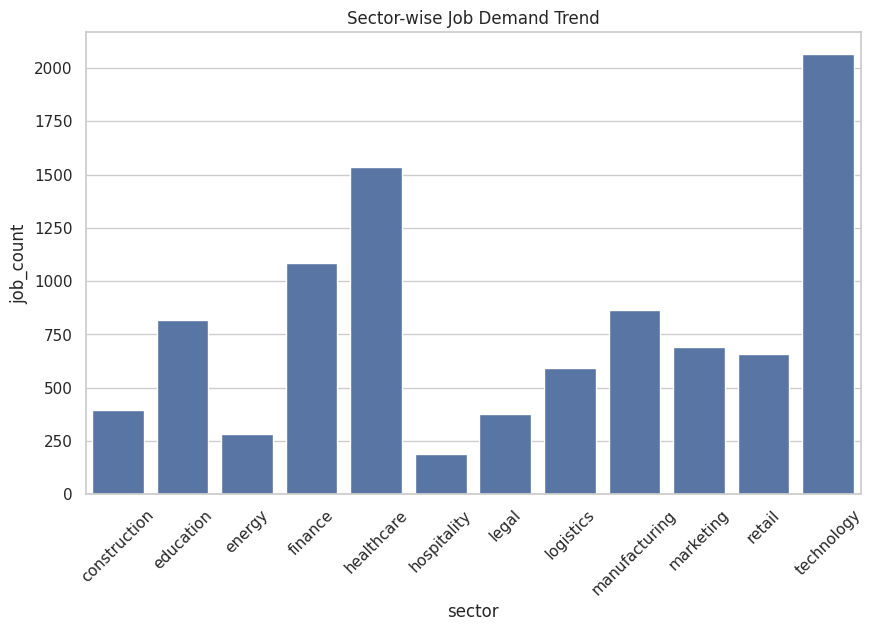

In [ ]:
sns.barplot(data=sector_monthly_trend, x="sector", y="job_count")
plt.title("Sector-wise Job Demand Trend")
plt.xticks(rotation=45)
plt.show()

# **Top In-Demand Skills Analysis**

The most frequently requested skills are extracted and visualized to identify the competencies most valued by employers in the labor market.

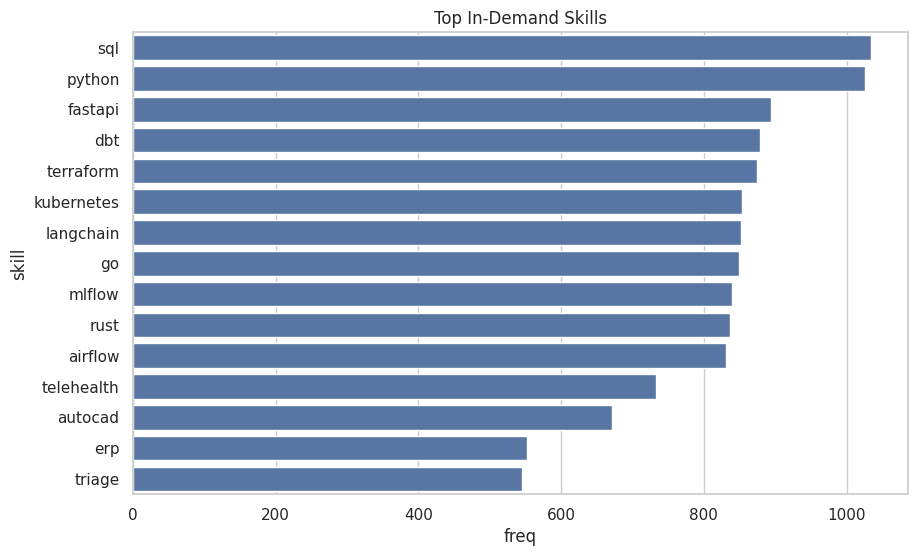

In [ ]:
top_skills = skill_freq.sort_values("freq", ascending=False).head(15)

sns.barplot(data=top_skills, x="freq", y="skill")
plt.title("Top In-Demand Skills")
plt.show()

# **Correlation Analysis of Geographic Metrics**

This section computes correlations between key labor market indicators such as job volume, salary, sector diversity, and company presence. The heatmap helps reveal relationships and patterns among these variables that may influence employment opportunities.

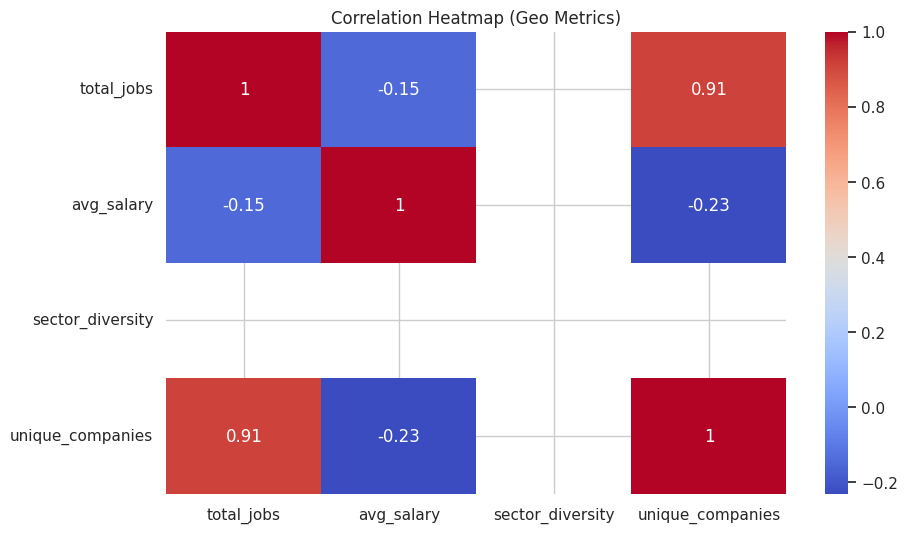

In [ ]:
corr = geo_heatmap[["total_jobs","avg_salary","sector_diversity","unique_companies"]].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap (Geo Metrics)")
plt.show()